In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")


### line ploting using seaborn

In [9]:
dimonds=pd.read_csv(r"C:\Users\chidv\Downloads\Data_sets\diamonds.csv")
dimonds

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


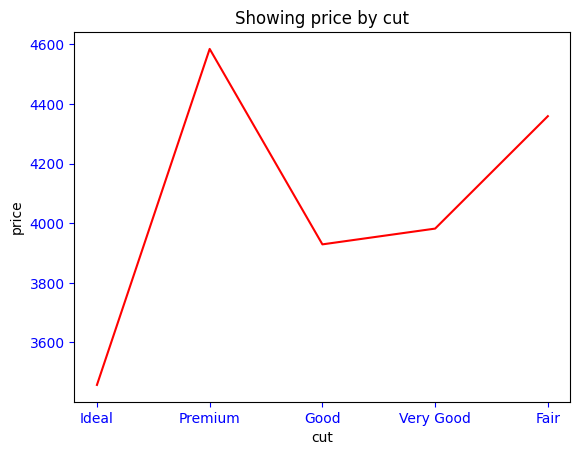

In [10]:
#line plots that is showing price by cut
plt.title("Showing price by cut")
sb.lineplot(data=dimonds,x='cut',y='price',errorbar=None,color="red")
plt.tick_params(axis='y',colors='blue')
plt.tick_params(axis='x', colors='blue')
plt.show();

<Axes: xlabel='cut', ylabel='price'>

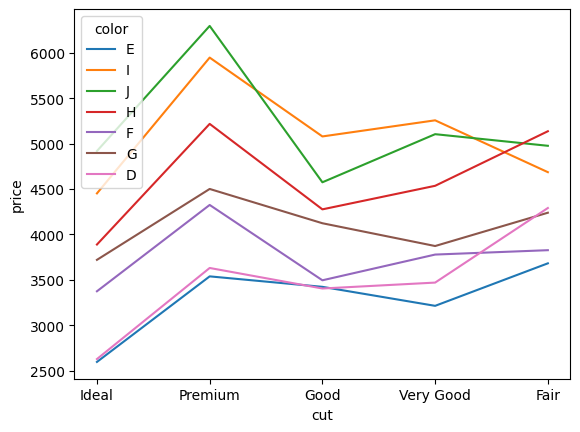

In [11]:
sb.lineplot(data=dimonds,x='cut',y='price',hue='color',errorbar=None,color="red")

In [12]:
hyper=pd.read_csv(r"C:\Users\chidv\Downloads\Data_sets\hypertension_dataset.csv")
hyper

,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,...,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230,160,79,Never,27.9,Low,Yes,...,6.1,80,100,75,72,179,Female,Primary,Unemployed,High
1,Spain,34,36.2,201,120,84,Never,27.5,High,Yes,...,9.8,56,77,47,90,113,Male,Secondary,Unemployed,High
2,Indonesia,73,18.2,173,156,60,Current,1.8,High,Yes,...,5.2,75,162,56,81,101,Male,Primary,Employed,Low
3,Canada,60,20.3,183,122,94,Never,11.6,Moderate,Yes,...,7.5,71,164,93,94,199,Female,Secondary,Retired,High
4,France,73,21.8,296,91,97,Never,29.1,Moderate,Yes,...,5.0,52,108,74,226,157,Female,Primary,Employed,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174977,India,51,39.4,266,174,82,Never,10.3,Low,Yes,...,9.5,96,172,72,100,95,Female,Tertiary,Employed,Low
174978,Australia,89,39.0,243,104,94,Never,7.2,Moderate,Yes,...,6.2,63,81,66,140,124,Female,Primary,Employed,High
174979,India,43,36.5,266,109,98,Former,22.9,Low,Yes,...,10.0,62,139,39,93,71,Male,Secondary,Employed,High
174980,Germany,48,18.3,294,134,84,Never,15.3,High,No,...,4.7,53,112,37,57,87,Male,Primary,Retired,High


In [13]:
agg=hyper.groupby(['Country'],as_index=False)[['Glucose']].agg('mean')
agg


,Country,Glucose
0,Argentina,134.681181
1,Australia,134.371484
2,Brazil,135.049755
3,Canada,134.362604
4,China,134.760396
5,France,134.914054
6,Germany,134.320027
7,India,134.120183
8,Indonesia,134.221713
9,Italy,134.755060


<Axes: xlabel='cut', ylabel='price'>

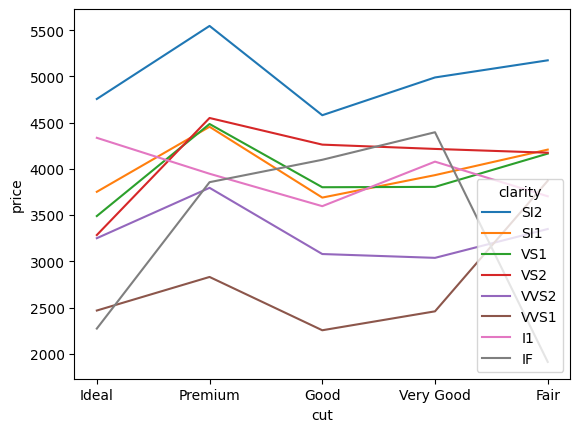

In [14]:
#Area chat 
sb.lineplot(data=dimonds,x='cut',y='price',hue='clarity',errorbar=None,color="red",)

### No — Seaborn does not support `pie`,`stacked` charts.

## ⚡ No – Seaborn does not have a direct area plot function like Matplotlib (plt.fill_between) or Plotly (px.area)

In [15]:
agg=dimonds.groupby(['cut'],as_index=False)[['price']].agg('sum')
agg['price']=agg.price.values/agg.price.values.sum()*100


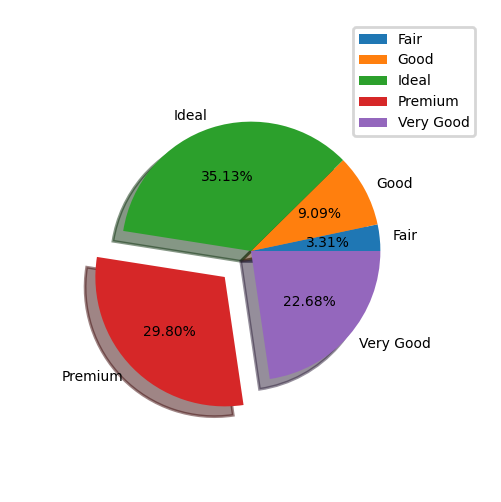

In [16]:
plt.figure(figsize=(3,3),dpi=200)
plt.pie(agg.price,labels=agg.cut,autopct='%.2f%%',textprops={'fontsize': 5,'color':'black'},radius=0.7,explode=[0,0,0,0.2,0],shadow=0.02)
plt.legend(fontsize=5)
plt.show();

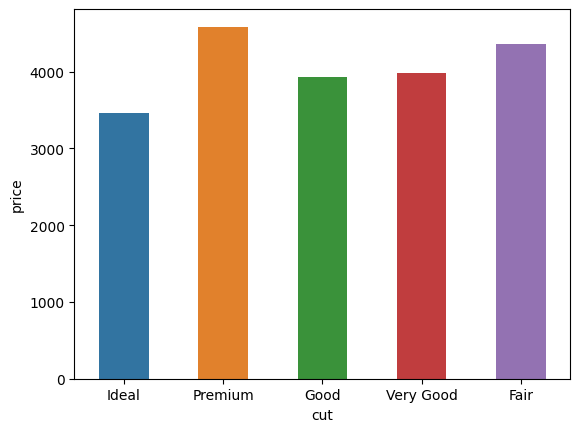

In [17]:
sb.barplot(data=dimonds,x='cut',y='price',errorbar=None,legend=False,width=0.5,palette=sb.color_palette())
plt.show();

In [18]:
agg=dimonds.groupby(['cut','clarity'],as_index=False)['price'].agg('mean').unstack()
print(agg)

cut    0            Fair
       1            Fair
       2            Fair
       3            Fair
       4            Fair
                ...     
price  35    4988.688095
       36    3805.353239
       37    4215.759552
       38    2459.441065
       39    3037.765182
Length: 120, dtype: object


In [19]:
#grouped Barchart
plt.figure(figsize=(18,8))
sb.barplot(x=agg.cut,y=agg.price,hue=agg.clarity,errorbar=None,stacked=)


SyntaxError: expected argument value expression (3812235132.py, line 3)

# KDE Charts

### it is like wave structure to identift the distribution of data 

<Axes: xlabel='price', ylabel='Density'>

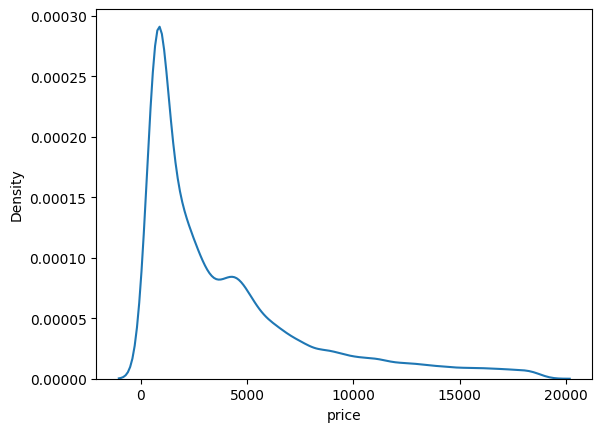

In [20]:
sb.kdeplot(data=dimonds,x='price')

# KDE Plot of Diamond Prices

### Axes
- **X-axis (`price`)**: Diamond prices (0 to ~20,000).  
- **Y-axis (`Density`)**: Probability density (not counts).  
  - The **area under the curve = 1**.

---

### Interpretation
1. **Sharp Peak near ~\$1000**
   - Most diamonds are priced around **\$1000–\$2000**.
   - This creates the tall spike in the KDE.

2. **Secondary bump around ~\$4000–\$5000**
   - A noticeable number of diamonds fall in this mid-price range.

3. **Long Right Tail**
   - A few diamonds are very expensive (up to ~\$20,000).
   - These are rare, so the curve gradually tapers off to the right.

---

### Why Density Values Are Small (~0.0002)
- KDE normalizes the curve so that the **total area under it = 1**.
- Since prices span a large range (0–20k), the probability density at any exact price is very small.
- Example:  
  - A density of `0.0002` means that in a **narrow \$1 interval**, the probability of finding a diamond is about **0.02%**.

---

### Conclusion
- The price distribution is **right-skewed** (most diamonds are cheap, a few are extremely costly).  
- KDE provides a smooth estimate of the probability distribution, helping us see the **peaks and spread** clearly.  


# Relating KDE Density to Counts (53,940 rows)

- KDE y-axis (Density) is scaled so that **total area under the curve = 1**.  
- To convert density → probability → counts:

Counts in interval ≈ Density × Interval Width × Total Rows

---

### Example
- Density = **0.00030**
- Interval width = **100 (price units)**
- Total rows = **53,940**

Counts ≈ 0.00030 × 100 × 53,940  
       ≈ **1,618 diamonds**

---

✅ So, around **1,600 diamonds** are expected in the price range **950–1050**.


Text(0.5, 0, 'price in $')

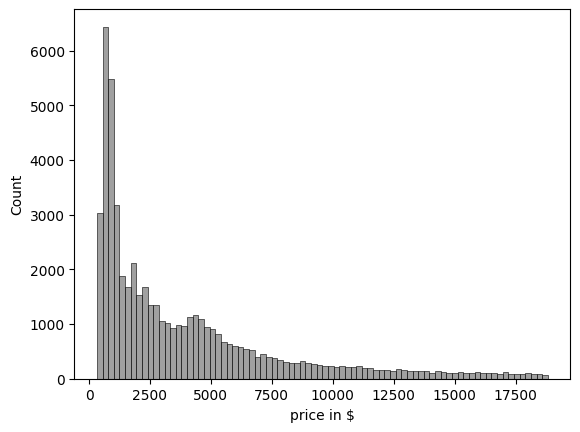

In [21]:
#histograom Also it also used to analyse the single numerical data
sb.histplot(data=dimonds,x='price',color='grey')
plt.xlabel("price in $")

Text(0.5, 0, 'price in $')

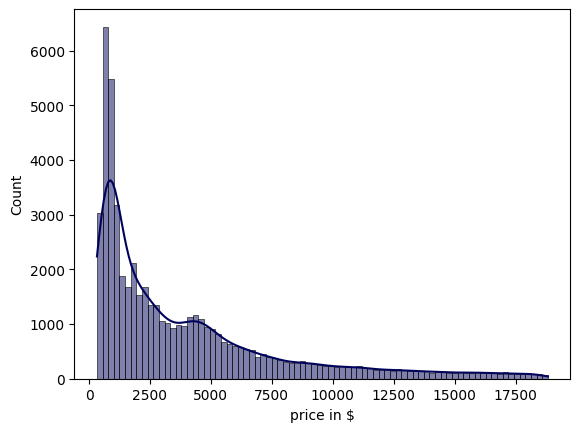

In [22]:
#COBINATION OF kde and hist 
sb.histplot(data=dimonds,x='price',color = "xkcd:dark blue",kde=True,palette=sb.color_palette())
plt.xlabel("price in $")

Text(0.5, 0, ' Depth of dimonds ')

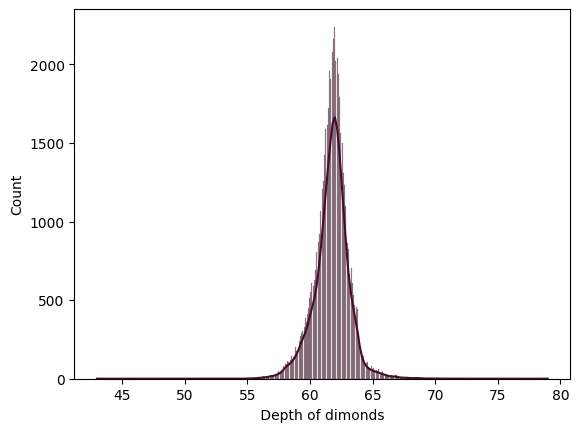

In [23]:
sb.histplot(data=dimonds,x='depth',kde=True,color='#450c27',legend=True)
plt.xlabel(" Depth of dimonds ")

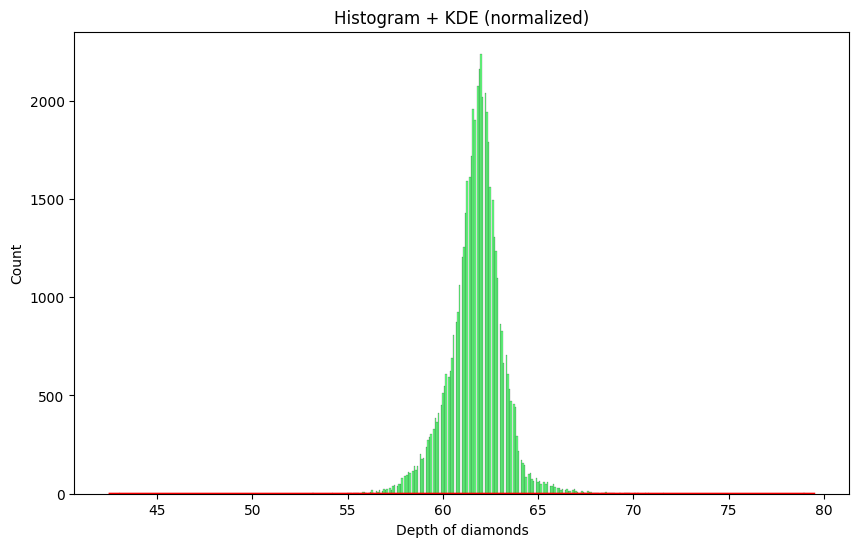

In [24]:
#using two colors We define them seperately
plt.figure(figsize=(10,6))
sb.histplot(data=dimonds,x='depth',kde=False,color='#33FF57')
sb.kdeplot(data=dimonds,x='depth',color='red')
plt.xlabel(" Depth of dimonds ")
plt.xlabel("Depth of diamonds")
plt.title("Histogram + KDE (normalized)")
plt.show()


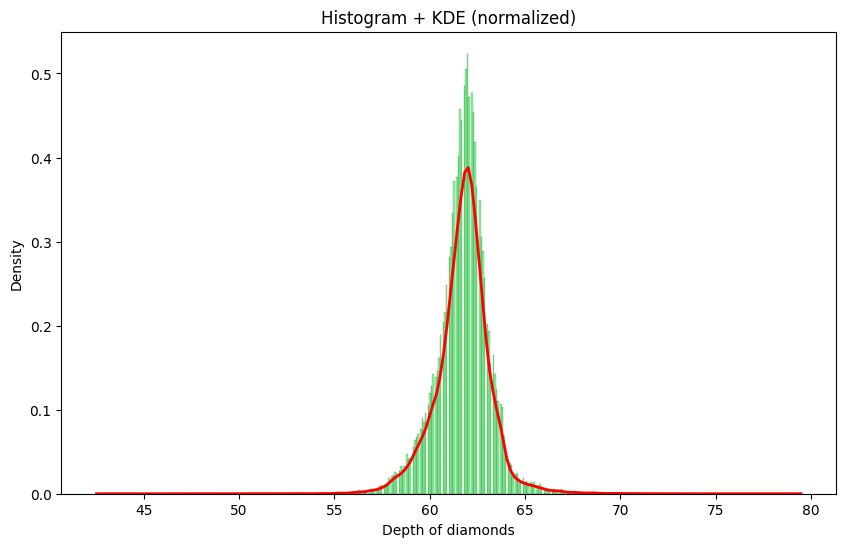

In [25]:
plt.figure(figsize=(10,6))

# Histogram as density (area = 1)
sb.histplot(data=dimonds, x='depth', stat='density', color='#33FF57', alpha=0.6)

# KDE line (also density)
sb.kdeplot(data=dimonds, x='depth', color='red', linewidth=2)

plt.xlabel("Depth of diamonds")
plt.title("Histogram + KDE (normalized)")
plt.show()


<Axes: xlabel='price', ylabel='Count'>

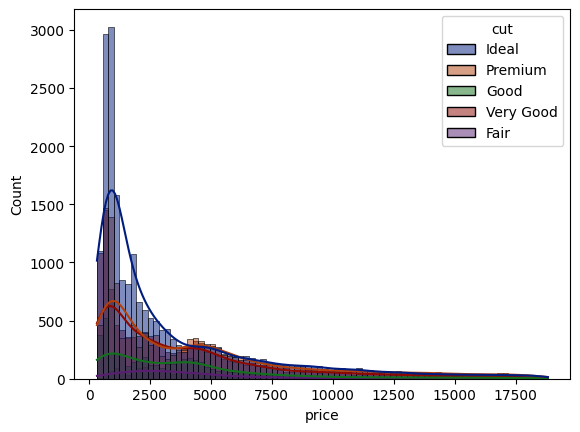

In [26]:

#diffrent catories in kde+hist

sb.histplot(data=dimonds,hue='cut',x='price',kde=True,palette=sb.color_palette("dark"))

<Axes: xlabel='carat', ylabel='price'>

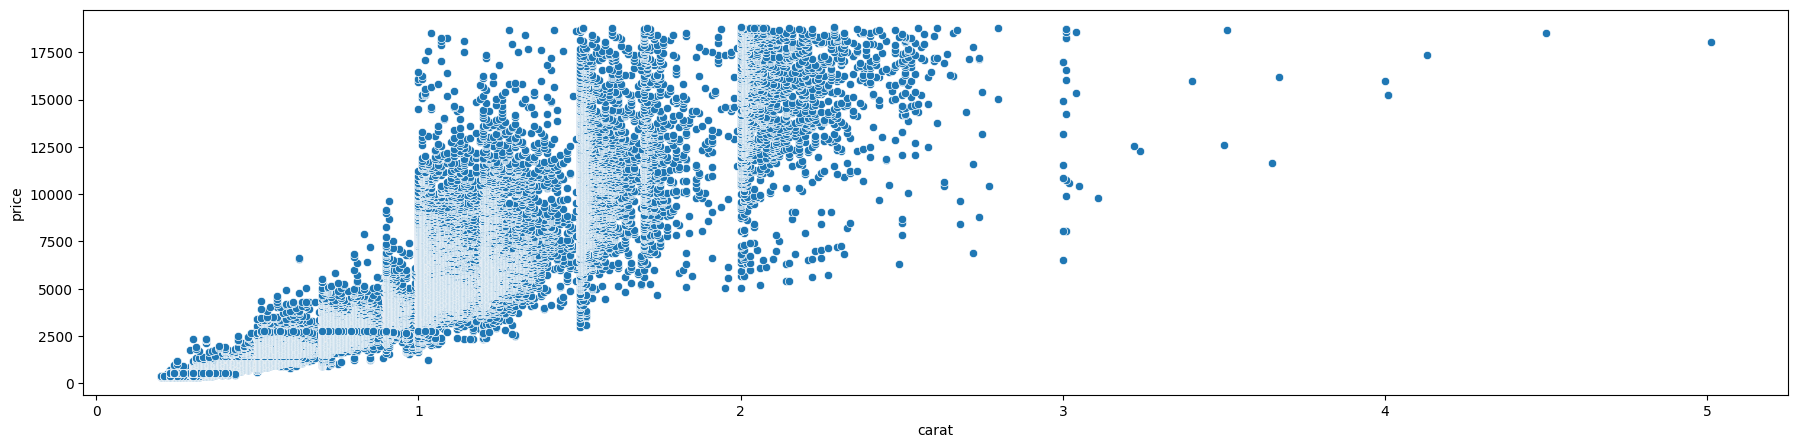

In [28]:
## Scattered plot
plt.figure(figsize=(22,5))
sb.scatterplot(data=dimonds,x='carat',y='price',)

In [29]:
#for smaller info iam taking small dataset
iris = pd.read_csv(r"C:\Users\chidv\Downloads\Data_sets\Iris.csv")
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

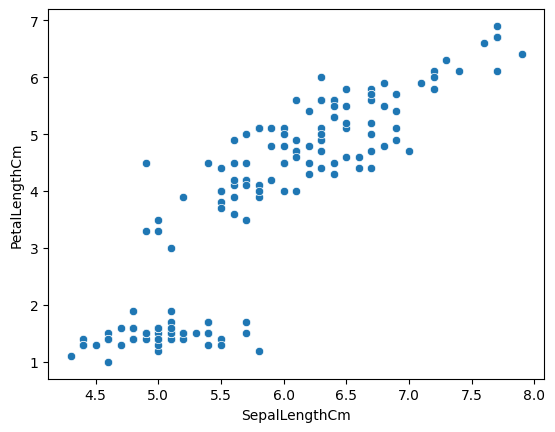

In [30]:
sb.scatterplot(data=iris,x='SepalLengthCm',y='PetalLengthCm')

### we observed that if the sepa length is decreses then petalength too


<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

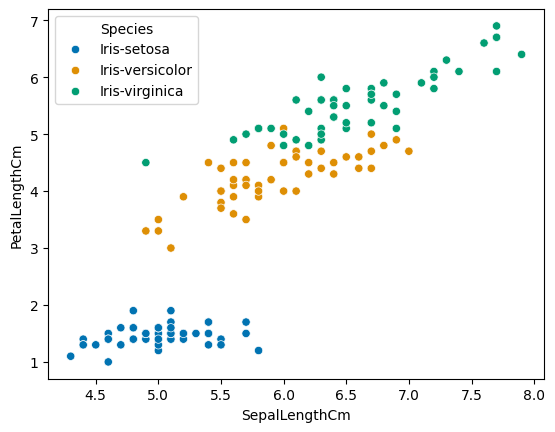

In [31]:
#scattered plot among multiple conditions[using that one catogery

sb.scatterplot(data=iris,x='SepalLengthCm',y='PetalLengthCm',hue='Species',palette=sb.color_palette('colorblind',3))

## `Strip plot` : a single-axis scatter plot that is used to visualise the distribution of many individual one-dimensional values

<Axes: xlabel='price'>

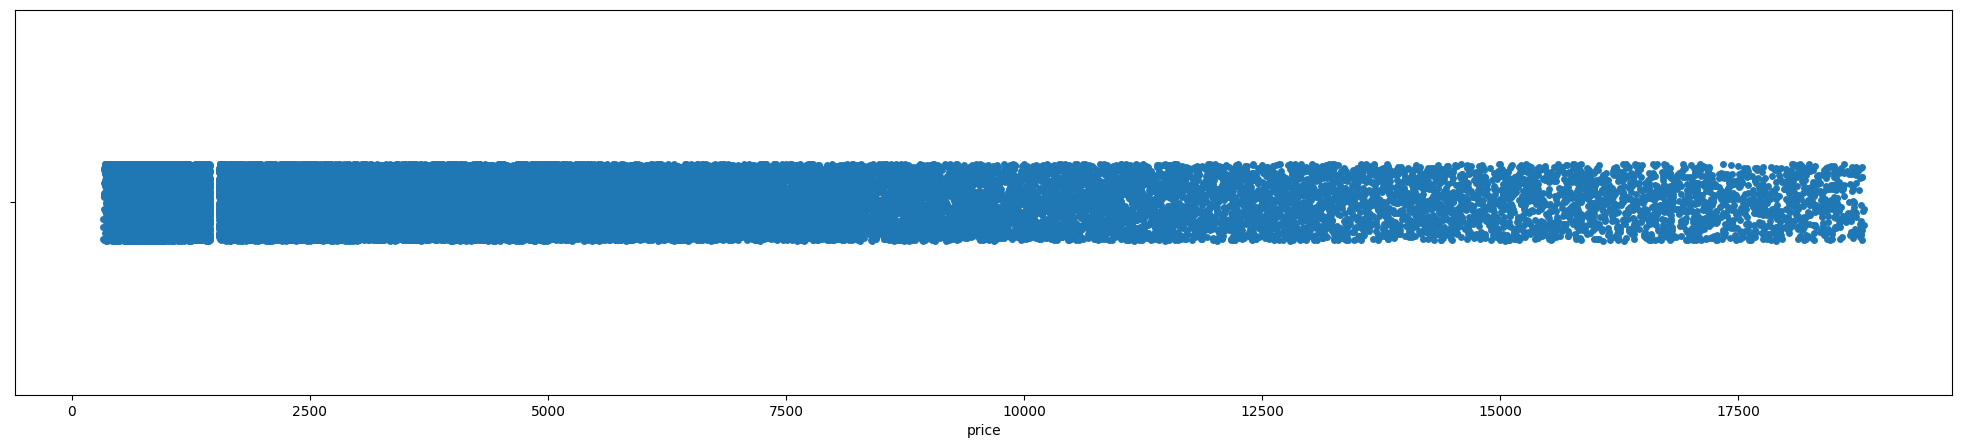

In [32]:
plt.figure(figsize=(25,5)) 
sb.stripplot(data=dimonds,x='price')

In [33]:
# very big but we need to use the smaller data
iris = pd.read_csv(r"C:\Users\chidv\Downloads\Data_sets\Iris.csv")
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


<Axes: xlabel='SepalLengthCm'>

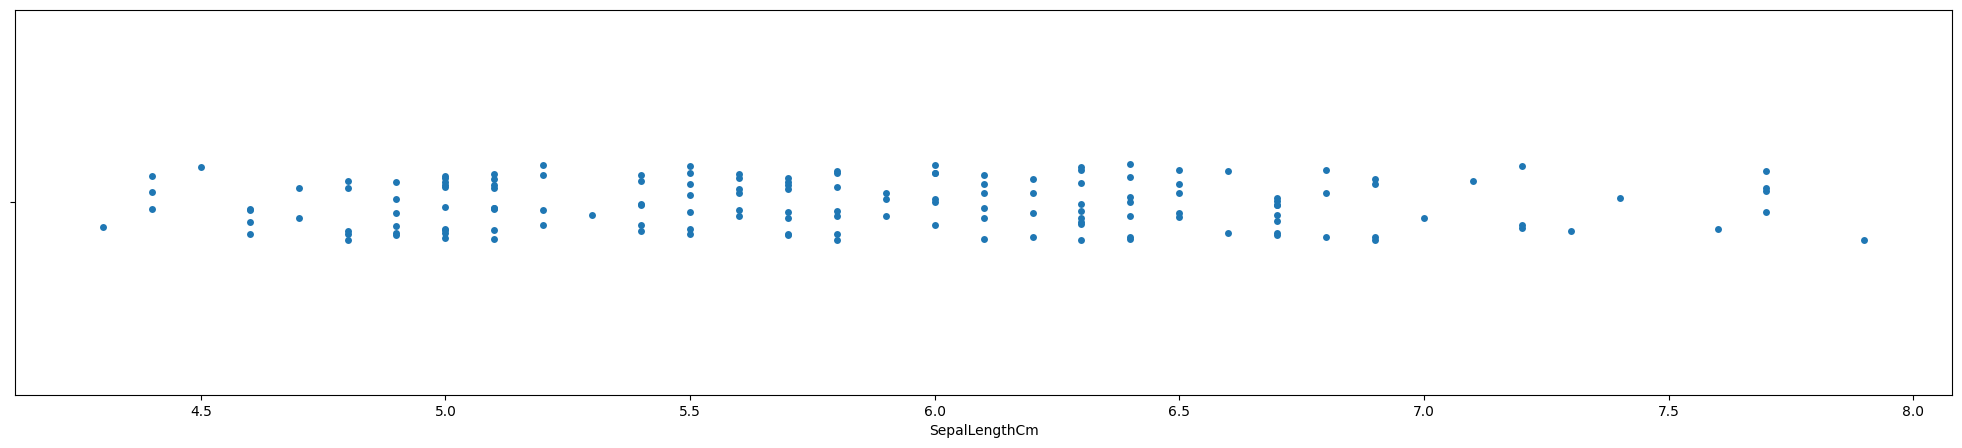

In [34]:
plt.figure(figsize=(25,5)) 
sb.stripplot(data=iris,x='SepalLengthCm')

In [35]:
#10. Cat plot
#The categorical plot shows the relationship between a numerical and one or more categorical variables in the data.

#opposite to the scatter plot 
# we analysize one numerical and one or more catagoreical data


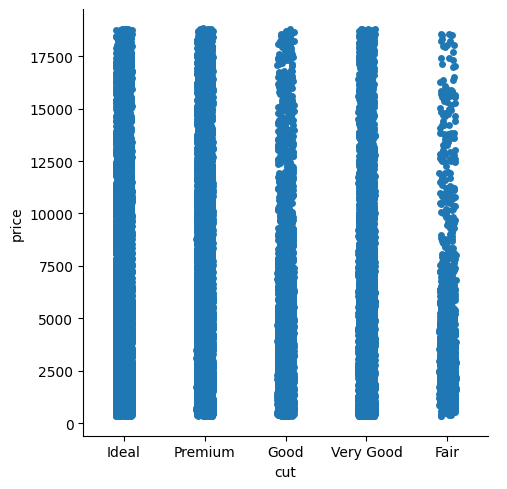

In [37]:
sb.catplot(data=dimonds,x='cut',y='price')


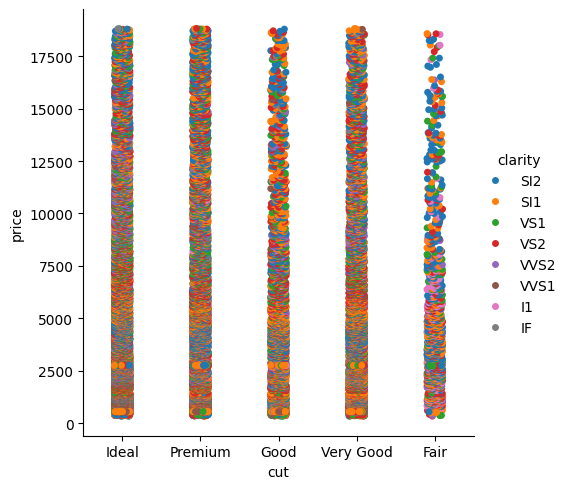

In [38]:
sb.catplot(data=dimonds,x='cut',y='price',hue='clarity')

In [39]:
dimonds.clarity.unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [40]:
#we use the smaller or reducd dataframe for better understanding
reduced_Df=dimonds[(dimonds.clarity=='VVS1')&(dimonds.depth<60)]
reduced_Df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
84,85,0.26,Good,E,VVS1,57.9,60.0,554,4.22,4.25,2.45
257,258,0.76,Premium,I,VVS1,58.8,59.0,2790,6.00,5.94,3.51
296,297,0.70,Fair,G,VVS1,58.8,66.0,2797,5.81,5.90,3.44
356,357,0.57,Fair,E,VVS1,58.7,66.0,2805,5.34,5.43,3.16
577,578,0.51,Very Good,D,VVS1,59.9,58.0,2834,5.16,5.19,3.10
...,...,...,...,...,...,...,...,...,...,...,...
52956,52957,0.24,Very Good,F,VVS1,58.7,59.0,552,4.04,4.10,2.39
52959,52960,0.24,Very Good,E,VVS1,59.7,58.0,552,4.07,4.10,2.44
52975,52976,0.24,Good,F,VVS1,58.3,57.0,552,4.10,4.14,2.40
53032,53033,0.70,Premium,H,VVS1,58.3,60.0,2603,5.83,5.80,3.39


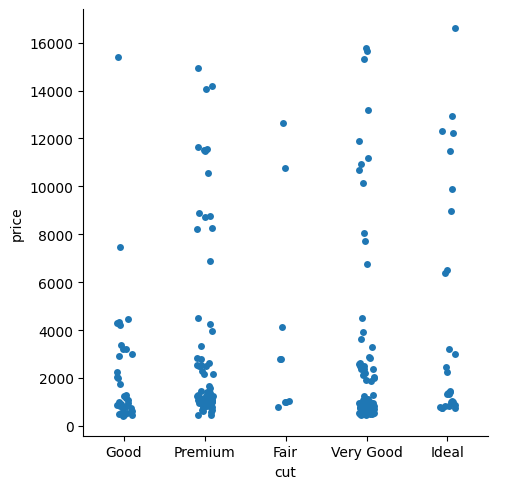

In [41]:

sb.catplot(data=reduced_Df,x='cut',y='price')

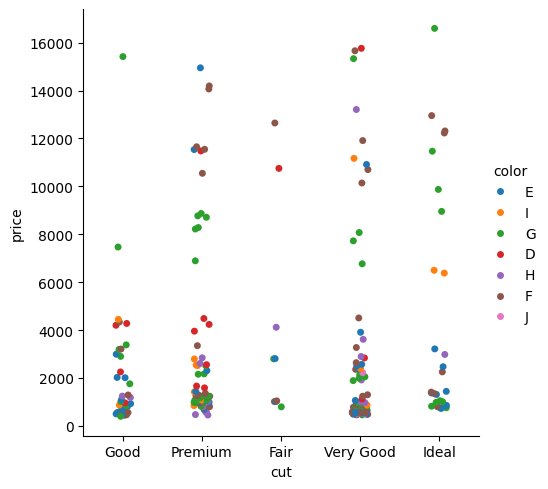

In [42]:
sb.catplot(data=reduced_Df,x='cut',y='price',hue='color')

<Axes: xlabel='price'>

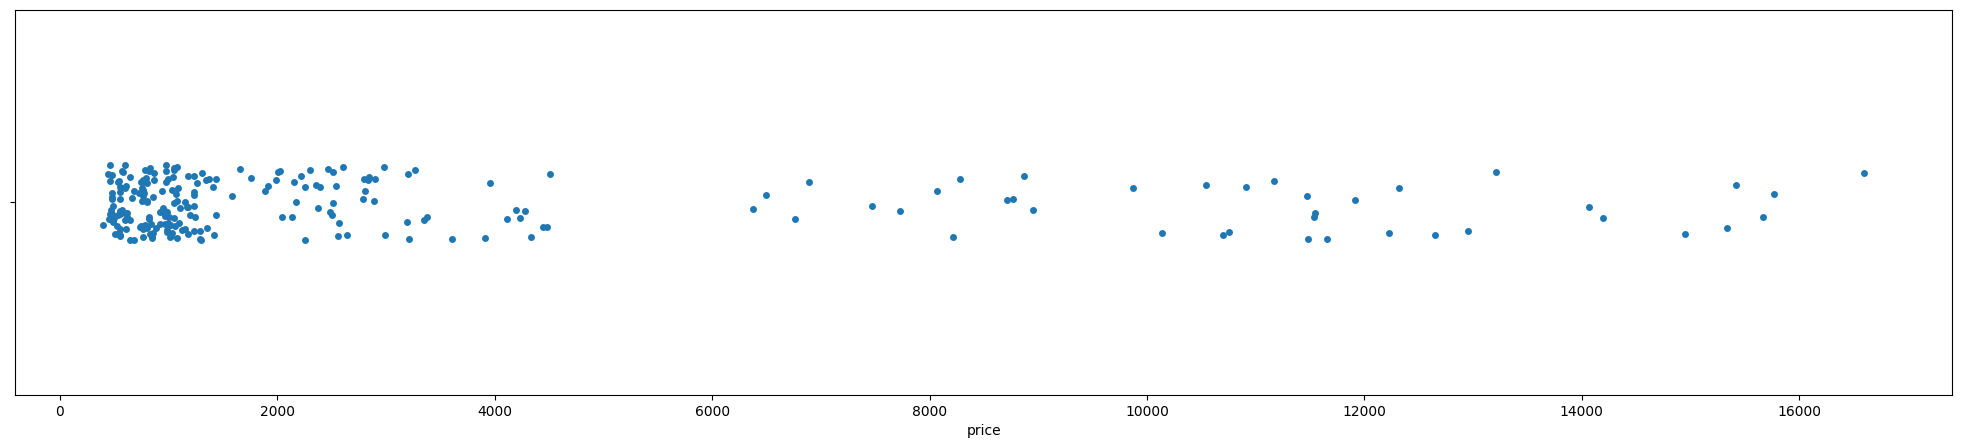

In [43]:
plt.figure(figsize=(25,5)) 
sb.stripplot(data=reduced_Df,x='price')

<Axes: xlabel='depth', ylabel='price'>

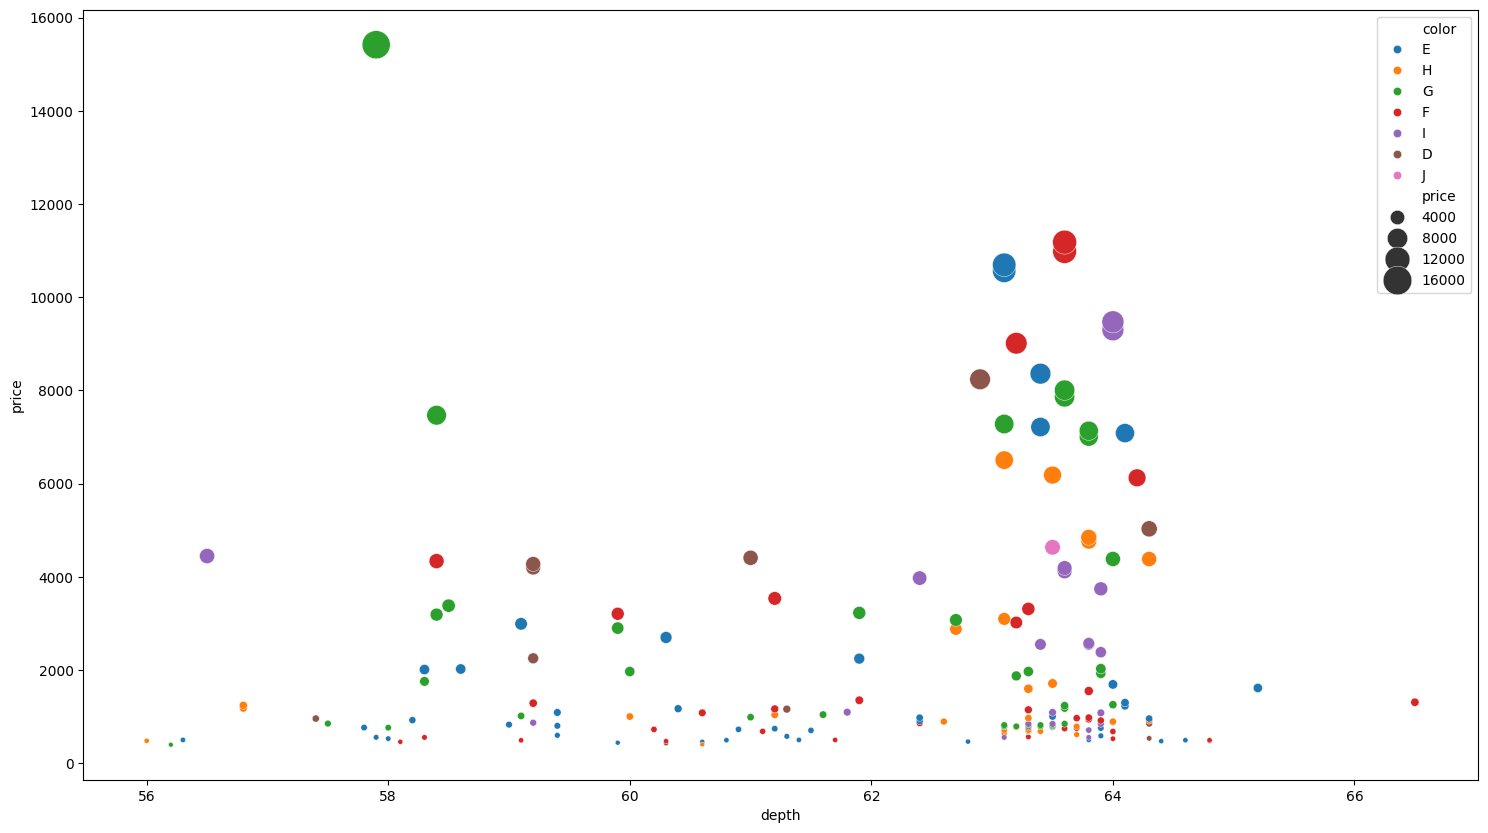

In [44]:
#bubble chart 
# IT IS ALSO USED for the smaller datasets only'
# there is no seperate methods to reperesent the bubble cha we use only scatter plot and gives size 
plt.figure(figsize=(18,10))
sb.scatterplot(data=dimonds[(dimonds.cut == "Good") & (dimonds.clarity == "VVS1")],x='depth',hue='color',y='price',size=dimonds.price,sizes=(10,500))

# HEAT Map 
- basically heat map is used to represent the matrixed data 

In [3]:
# how we get the matrix type data , by using the cross tab
agg_d=pd.crosstab(index=dimonds.cut,columns=dimonds.clarity)
agg_d

clarity,I1,IF,SI1,SI2,VS1,VS2,VVS1,VVS2
cut,,,,,,,,
Fair,210,9,408,466,170,261,17,69
Good,96,71,1560,1081,648,978,186,286
Ideal,146,1212,4282,2598,3589,5071,2047,2606
Premium,205,230,3575,2949,1989,3357,616,870
Very Good,84,268,3240,2100,1775,2591,789,1235


<Axes: xlabel='clarity', ylabel='cut'>

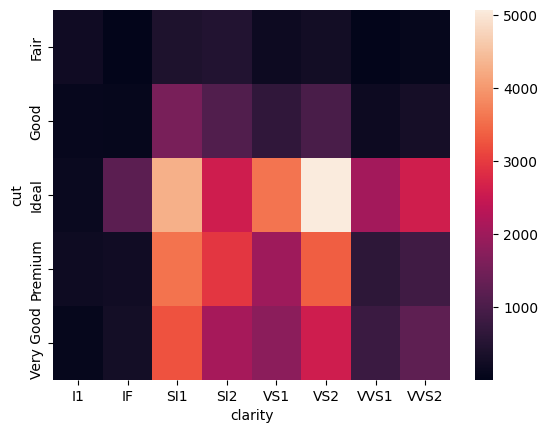

In [4]:
sb.heatmap(data=agg_d)

<Axes: xlabel='clarity', ylabel='cut'>

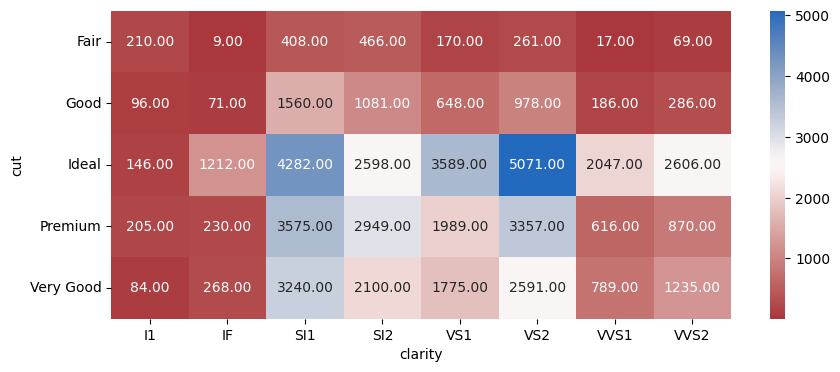

In [5]:
plt.figure(figsize=(10,4))

sb.heatmap(data=agg_d,annot=True,fmt='.2F',cmap=sb.cm.vlag_r)

In [ ]:
# LIST of color maps available 
lst=['Grey', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']

In [ ]:
plt.figure(figsize=(10,4))

sb.heatmap(data=agg_d,annot=True,fmt='.2F',cmap='PuBuGn')

## corelation of dimonds dataset


In [ ]:
corelation_Matrix=dimonds.corr(numeric_only=True)
corelation_Matrix

In [ ]:
#converting the corelation into heatmap
plt.figure(figsize=(10,4))
sb.heatmap(corelation_Matrix,cmap='berlin',annot=True)

In [ ]:
#we only want the half matrix


In [ ]:
#wee need to learn two more funtions in np


np.triu(np.ones_like(corelation_Matrix))

In [ ]:
np.tril(np.ones_like(corelation_Matrix))

In [ ]:
#we want the lower triange so we mask the upper triangle
upr=np.triu(corelation_Matrix)
plt.figure(figsize=(10,4))
sb.heatmap(corelation_Matrix,cmap='berlin',annot=True,mask=upr)

## Count Plot

In [ ]:
# count plot is mainly use to derermine the value counts '

sb.countplot(x=dimonds.cut,palette=sb.color_palette("bright"),legend=True);

In [ ]:
sb.countplot(dimonds.clarity,palette=sb.color_palette("deep"))

In [ ]:
# subplots in plt
fig,axes=plt.subplots(2,2)

dimonds.plot(x='depth',y='price',kind='scatter',ax=axes[0][0])

# Subplots in seaborn

In [ ]:
#seaborn didnot supports subplots directly instread it will used to create the plots that is used in subplots 
fif,axis=plt.subplots(2,2)

sb.kdeplot(data=dimonds,x='price',ax=axis[0][0])
sb.histplot(data=dimonds,x='depth',ax=axis[0][1])
sb.barplot(data=dimonds,x='cut',y='price',hue='clarity',ax=axis[1][0])
sb.stripplot(data=reduced_Df,x='cut',y='price',ax=axis[1][1])
    

plt.tight_layout()

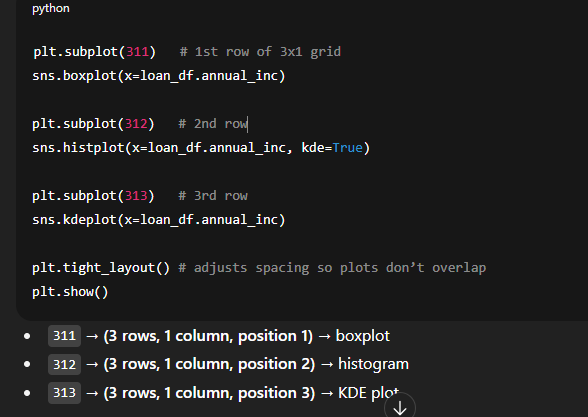

# Box Plot

### Basically box plot is use to determine the distribution and spread of data 
### it is also used to find the outliers of data

In [ ]:
sb.boxplot(data=dimonds,x='price')

In [ ]:
#we are Reducing the data
reduced_Df=dimonds[(dimonds.clarity=='VVS1')&(dimonds.depth<60)]
reduced_Df

In [ ]:
reduced_Df.describe()

In [ ]:
sb.boxplot(data=reduced_Df,x='price')

In [ ]:
#that midding lines describes the 50% of data  as per above table
                                     median (50%)=1133.500000
#we also conclude in the img also middile line reprents 1133 value only

# Outlier :
- outlier is a data point that significantly deviates from the rest of the dataset

### left hand most line preprents 25% ------> below 25% value undergoes Outlier
### right hand most line preprents 75% ------> Above 75% valaues also undergoes oulires

#### how to calculate that 

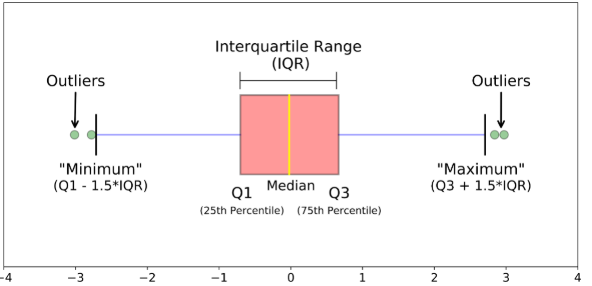

# IQR= median

In [ ]:
sb.boxplot(data=reduced_Df,x='price')

In [ ]:
 median (50%)=1133.500000 as per description

In [ ]:
2879.750000+1.5*1133.500000    #check the quantalie Q values in describe 

# so starting from  4580.0 all are outlers

In [ ]:
sb.boxplot(data=reduced_Df,x='price')

# More examples 

In [ ]:
reduced_Df=dimonds[(dimonds.clarity=='VVS1')&(dimonds.depth<62)]
reduced_Df

In [ ]:
sb.boxplot(data=reduced_Df,x='depth',color='red')#so outliers are lying on lHs 

In [ ]:
plt.figure(figsize=(16,12))
sb.boxplot(data=reduced_Df,x='price',hue='cut')

# Removing Outliers

In [ ]:
sb.boxplot(data=reduced_Df[reduced_Df.cut=='Premium'],x='price',color='Brown')

### iam removing the outliers which price greater than 12500

In [ ]:
sb.boxplot(data=reduced_Df[(reduced_Df.cut=='Premium')&(reduced_Df.price<12500)],x='price',color='#f6a192')

In [ ]:
hr=pd.read_csv(r"C:\Users\chidv\Downloads\Data_sets\visualizationDF\HRDataset_v14.csv")
hr

In [ ]:
sb.pairplot(hr,kind='boxplot')

In [7]:
-3%12


9